In [2]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt


### Решаем задачу Коши с начальным условием в одной точке:

$y'=f(x,y)$,

$x\in[x_0;x_0+X]$,

$y(x_0)=y_0$

### Методы

#### Метод Эйлера:

$y_{j+1} = y_j + h*f(x_j,y_j)$  -  Работает с погрешностью порядка $O(h)$, что достаточно много

#### Метод Эйлера улучшенный

$y_{j+1 old} = y_j + h*f(x_j,y_j)$

$y_{new} = y_j + h/2*(f(x_j,y_j) + f(x_{j+1},y_{j+1 old}) )$ - уже $O(h^2)$

#### Метод Рунге-Кутта

$\alpha_2, .... , \alpha_q$


$\rho_1, .... , \rho_q$

$\beta_{ij}$

$0<j<i<=q$

$k_1(h) = hf(x,y)$

$k_2(h) = hf(x+\alpha_2*h,y+\beta_{21}*k_1(h))$

...

$k_q(h) = hf(x+\alpha_2*h,y+\beta_{21}*k_1(h)+...+\beta_{q,q-1}*k_{q-1}(h))$

$y(x+h) = y(x) + \sum_{i=1}^{q}\rho_i*k_i$ - будем брать q=4, такого ограничения достаточно для хорошего прогноза $O(h^4)$,



### Решим диффурчик

$\frac{dy}{dx} = x^3 - 2xy + 6$

Сначала аналитическое решение

In [3]:
xs = sym.symbols('xs')
ys = sym.Function('ys')

equation = sym.Eq(ys(xs).diff(xs), xs**3 - 2*xs*ys(xs) + 6)

sol = sym.dsolve(equation) #общ решение

nsol = sym.dsolve(equation, ys(xs), ics = {ys(0):0}) #решение с нач условием

In [4]:
print(sol)
print(nsol)

Eq(ys(xs), C1*exp(-xs**2) + xs**2/2 - 1/2 + 3*sqrt(pi)*exp(-xs**2)*erfi(xs))
Eq(ys(xs), xs**2/2 - 1/2 + 3*sqrt(pi)*exp(-xs**2)*erfi(xs) + exp(-xs**2)/2)


Нарисуем график

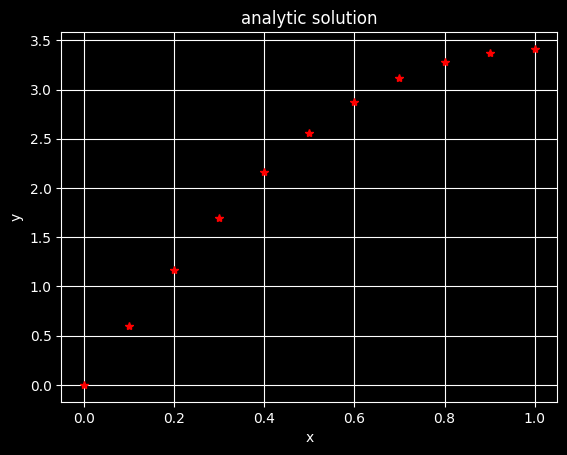

In [4]:
a = 0
b = 1
hx = 0.1 #шаг
n = int((b-a)/hx)+1 #добавляем единицу чтобы взять и граничную точку отрезка
x = np.zeros(n)
n = np.size(x)
ya = np.zeros(n)

x[0] = a
for i in range(1,n):
    x[i] = x[i-1] + hx
for i in range(0,n):
    ya[i] = float(sym.Subs(nsol.rhs,xs,x[i]))

plt.title('analytic solution')
plt.xlabel('x')
plt.ylabel('y')

plt.grid()
plt.plot(x, ya, 'r*')
plt.show()


Теперь методы

### Эйлер

In [5]:
def f(x_d, y_d):
    return x_d**3 - 2*x_d*y_d + 6
ye = np.zeros(n)
ye[0] = 0
for i in range(0, n-1):
    ye[i+1] = ye[i] + hx * f(x[i], ye[i])

err = 0
for i in range(0,n):
    err = err + (ya[i] - ye[i])**2
err = np.sqrt(err/n)
res = 100*err / (np.max(ya) - np.min(ya))
print(res) # ошибку посмотрели

3.4464271986274797


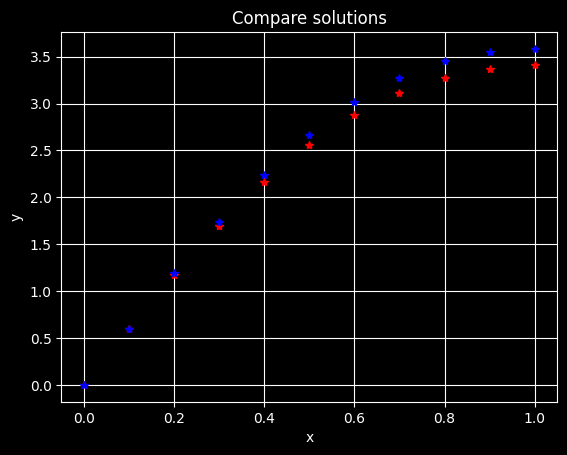

In [6]:
plt.title('Compare solutions')
plt.xlabel('x')
plt.ylabel('y')

plt.grid()
plt.plot(x, ya, 'r*', x, ye, "b*")
plt.show()


### Эйлер улучшенный с пересчетом

In [9]:
ye = np.zeros(n)
ye[0] = 0
for i in range(0, n-1):
    ye[i+1] = ye[i] + hx * f(x[i], ye[i]) #старый эйлер

yena = np.zeros(n)
for i in range(0, n-1):
    yena[i+1] = yena[i] + hx/2*(f(x[i], yena[i]) + f(x[i+1], ye[i+1]))

err = 0
for i in range(0,n):
    err = err + (ya[i] - yena[i])**2
err = np.sqrt(err/n)
res = 100*err / (np.max(ya) - np.min(ya))
print(res) # ошибку посмотрели

0.9364813677299139


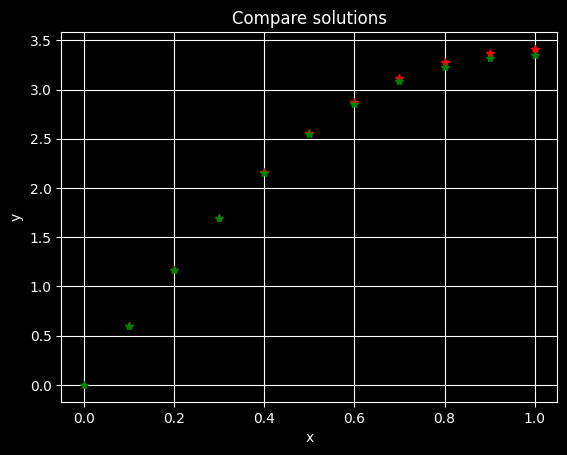

In [8]:
plt.title('Compare solutions')
plt.xlabel('x')
plt.ylabel('y')

plt.grid()
plt.plot(x, ya, 'r*', x, yena, "g*")
plt.show()


### Рунге-Кутта

Для q=4 уравнения выглядят так:

$y(x+h) = y(x) + 1/6(k_1 + 2k_2 + 2k_3 +k_4)$

где:

$k_1 = hf(x,y)$

$k_2 = hf(x+h/2, y+k_1/2)$

$k_3 = hf(x+h/2, y+k_2/2)$

$k_4 = hf(x+h, y+k_3)$

In [10]:
yk = np.zeros(n)
yk[0] = 0

for i in range(0, n-1):
    y_cur = yk[i]
    x_cur = x[i]

    k_1 = hx*f(x_cur, y_cur)
    k_2 = hx*f(x_cur+hx/2, y_cur + k_1/2)
    k_3 = hx*f(x_cur+hx/2, y_cur + k_2/2)
    k_4 = hx*f(x_cur+hx, y_cur + k_3)

    yk[i+1] = y_cur + (k_1 + 2*k_2 + 2*k_3 + k_4)/6

err = 0
for i in range(0,n):
    err = err + (ya[i] - yk[i])**2
err = np.sqrt(err/n)
res = 100*err / (np.max(ya) - np.min(ya))
print(res)

0.00023575529809519489


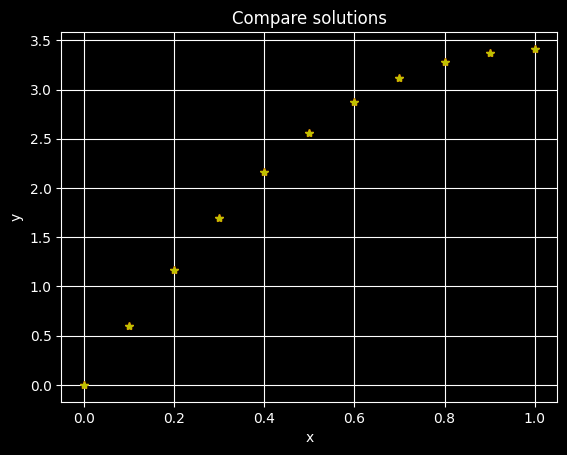

In [11]:
plt.title('Compare solutions')
plt.xlabel('x')
plt.ylabel('y')

plt.grid()
plt.plot(x, ya, 'r*', x, yk, "y*")
plt.show()